# BrushCue Example: Dark Academia Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/dark_academia_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/dark-academia-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


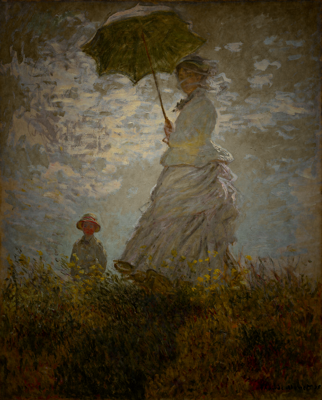

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
strength = 1.0
graded = input_image.color_transformer_shader(
    "let c = length(input.yz);\nlet h = atan2(input.z, input.y);\nlet colorful = smoothstep(0.01, 0.05, c);\nlet cool = band(h, 4.0, 1.6) * colorful * amount;\nlet green = band(h, 2.55, 0.9) * colorful * amount;\nlet red = band(h, 0.45, 0.8) * colorful * amount;\nlet h2 = h - 0.25 * green - 0.08 * red;\nlet c2 = c * (1.0 - 0.82 * cool) * (1.0 - 0.45 * green) * (1.0 + 0.12 * red);\nvar l = input.x - 0.04 * red;\nl = pow(max(l, 0.0), 1.0 + 0.28 * amount);\nlet hi = smoothstep(0.5, 1.0, l);\nl = l - 0.14 * hi * hi * amount;\nlet mid = exp(-pow((l - 0.42) / 0.22, 2.0));\nlet a = c2 * cos(h2) + 0.01 * mid * amount;\nlet b = c2 * sin(h2) + (0.032 * mid + 0.02 * cool) * amount;\nreturn vec4<f32>(l, a, b, input.w);",
    "fn band(h: f32, center: f32, width: f32) -> f32 {\n  let d = abs(atan2(sin(h - center), cos(h - center)));\n  return 1.0 - smoothstep(width * 0.5, width, d);\n}",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create().add("amount", strength),
)
bounds = input_image.bounds()
lamplit = graded.spacial_effect_shader(
    "let col = sample(position);\nlet uv = (position - origin) / size;\nlet d = (uv - vec2<f32>(0.5, 0.4)) * vec2<f32>(1.0, 1.1);\nlet pool = exp(-dot(d, d) * 3.4);\nlet l = col.x * mix(1.0, 0.38 + 0.62 * pool, amount);\nlet b = col.z + 0.012 * pool * amount;\nreturn vec4<f32>(l, col.y, b, col.w);",
    "",
    0.0,
    bc.Dictionary.create()
    .add("amount", strength)
    .add("origin", bc.Vector2f.from_components(bounds.min_x(), bounds.min_y()))
    .add("size", bc.Vector2f.from_components(bounds.width(), bounds.height())),
    bc.ColorRepresentation.oklab_a(),
)
grained = lamplit.film_grain((1.4 * strength), 150.0, 0.35, 51.0, 0.45, 300.0, 0.2)
graph = grained.crop(bounds)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
